# Homework 3: RAG for Science Question Answering

This notebook separates the **official HW3 pipeline** from an **optional advanced appendix**.

- Official evaluation set: `specified train.csv path random 50-question sample with `random_state=42`
- Official retrieval pipeline: FAISS + `BAAI/bge-m3` + dense retrieval `top_k=20` + cross-encoder re-ranking `top_n=3`
- Official generator: Ollama `llama3`
- Official score: reported only from the random 50-question `train.csv` sample

The appendix keeps the earlier science-only / DeepSeek / ensemble branch as a non-official extension.

## 0. Setup and GPU Check

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sentence_transformers import CrossEncoder

from official_eval import (
    EXAMPLES_JSON,
    HIT_RATE_CSV,
    INDEX_A_DIR,
    INDEX_B_DIR,
    OLLAMA_MODEL,
    RERANK_CANDIDATES_CSV,
    RERANK_MODEL_NAME,
    RERANK_SELECTED_JSON,
    RESULTS_CSV,
    SUMMARY_JSON,
    SYSTEM_PROMPT,
    TOP_K_INITIAL,
    TOP_N_FINAL,
    build_embeddings,
    build_mcq_prompt,
    build_raw_documents,
    chunk_stats,
    choose_device,
    load_or_build_faiss,
    load_or_collect_wiki_articles,
    make_chunkers,
    run_generation_eval,
    search_reranking_example_candidates,
    select_final_reranking_examples,
)

warnings.filterwarnings("ignore")
device = choose_device()
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")


C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda
GPU: NVIDIA GeForce RTX 4090


# Official HW3 Pipeline

## 1. Dataset and official random 50-question evaluation

The official evaluation setup must remain:

```python
official_train_df = pd.read_csv("train.csv")
official_eval_df = official_train_df.sample(n=50, random_state=42).reset_index(drop=True)
official_eval_df = official_eval_df.rename(columns={"prompt": "question"})
```

In [2]:
train_path = r"D:\\course\\rnnlstm\\HW3\\kaggle-llm-science-exam\\train.csv"
official_train_df = pd.read_csv(train_path)
official_eval_df = official_train_df.sample(n=50, random_state=42).reset_index(drop=True)
official_eval_df = official_eval_df.rename(columns={"prompt": "question"})

print(f"train.csv rows: {len(official_train_df)}")
print(f"official eval rows: {len(official_eval_df)}")
display(official_eval_df[["question", "A", "B", "C", "D", "E", "answer"]].head(3))


train.csv rows: 200
official eval rows: 50


,question,A,B,C,D,E,answer
0,What is the main sequence in astronomy?,The main sequence is a type of galaxy that con...,The main sequence is a type of black hole that...,The main sequence is a continuous and distinct...,The main sequence is a group of planets that o...,The main sequence is a type of nebula that is ...,C
1,"What is the ""ultraviolet catastrophe""?",It is a phenomenon that occurs only in multi-m...,It is the misbehavior of a formula for higher ...,It is the standing wave of a string in harmoni...,It is a flaw in classical physics that results...,It is a disproven theory about the distributio...,B
2,What is the Carnot engine?,The Carnot engine is a theoretical engine that...,The Carnot engine is an ideal heat engine that...,The Carnot engine is a real heat engine that o...,The Carnot engine is a theoretical engine that...,The Carnot engine is a real engine that operat...,B


## 2. Corpus and chunking

The retrieval corpus is built from 500 science-related Simple Wikipedia articles cached in
`official_wiki_articles.json`. This keeps the official notebook reproducible and avoids refetching the
full Wikipedia stream on every run.

In [3]:
articles = load_or_collect_wiki_articles(max_articles=500)
raw_documents = build_raw_documents(articles)

raw_total_chars = sum(len(doc.page_content) for doc in raw_documents)
raw_stats_df = pd.DataFrame(
    [
        {"metric": "Raw documents", "value": len(raw_documents)},
        {"metric": "Total characters", "value": raw_total_chars},
        {"metric": "Average document length", "value": round(raw_total_chars / len(raw_documents), 2)},
    ]
)
display(raw_stats_df)
print("Sample titles:", [article["title"] for article in articles[:10]])


,metric,value
0,Raw documents,500.00
1,Total characters,2252107.00
2,Average document length,4504.21


Sample titles: ['Air', 'Alanis Morissette', 'Farming', 'Arithmetic', 'Addition', 'Australia', 'Algebra', 'Atom', 'Astronomy', 'Anatomy']


In [4]:
splitter_a, splitter_b = make_chunkers()
docs_a = splitter_a.split_documents(raw_documents)
docs_b = splitter_b.split_documents(raw_documents)

chunk_stats_df = pd.DataFrame(
    [
        {"strategy": "Strategy A", "chunk_size": 500, "overlap": 50, **chunk_stats(docs_a)},
        {"strategy": "Strategy B", "chunk_size": 1000, "overlap": 200, **chunk_stats(docs_b)},
    ]
)
display(chunk_stats_df)


,strategy,chunk_size,overlap,chunks,avg_chars,min_chars,max_chars
0,Strategy A,500,50,6865,334.477058,2,500
1,Strategy B,1000,200,3204,732.730649,5,1000


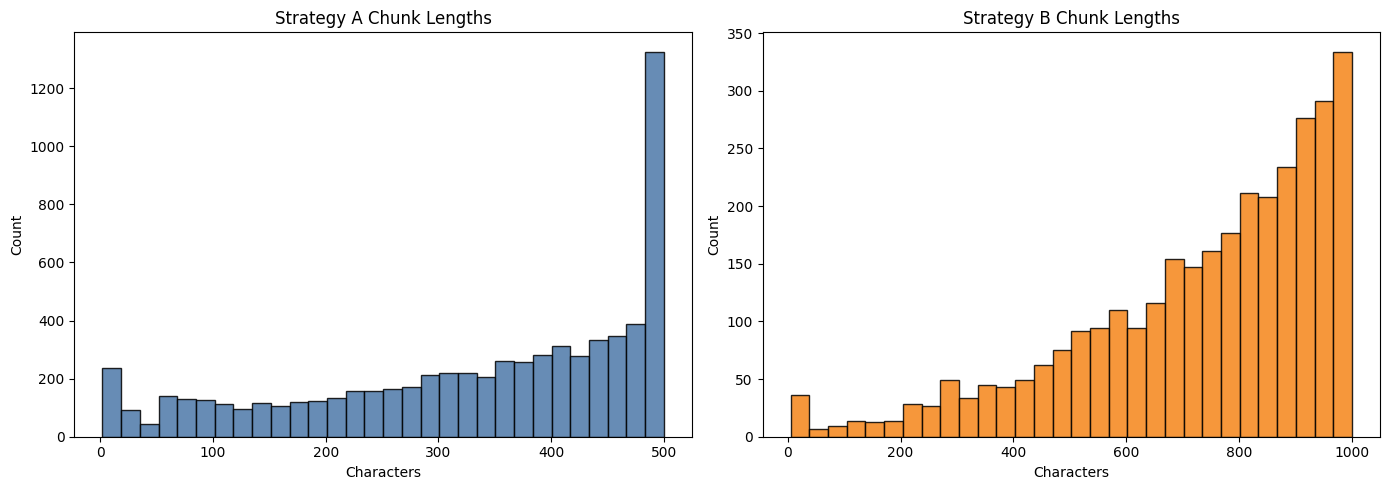

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sizes_a = [len(doc.page_content) for doc in docs_a]
sizes_b = [len(doc.page_content) for doc in docs_b]

axes[0].hist(sizes_a, bins=30, color="#4c78a8", alpha=0.85, edgecolor="black")
axes[0].set_title("Strategy A Chunk Lengths")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(sizes_b, bins=30, color="#f58518", alpha=0.85, edgecolor="black")
axes[1].set_title("Strategy B Chunk Lengths")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 3. FAISS index construction

Two FAISS indices are built with the same embedding model:

- Index A: Strategy A chunks
- Index B: Strategy B chunks

Embedding model: `BAAI/bge-m3` on GPU.

In [6]:
embeddings = build_embeddings(device)
vector_db_a = load_or_build_faiss(INDEX_A_DIR, docs_a, embeddings)
vector_db_b = load_or_build_faiss(INDEX_B_DIR, docs_b, embeddings)

index_df = pd.DataFrame(
    [
        {"index": "Index A", "strategy": "Fixed 500/50", "chunks": len(docs_a)},
        {"index": "Index B", "strategy": "Recursive 1000/200", "chunks": len(docs_b)},
    ]
)
display(index_df)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 43003.27it/s]

,index,strategy,chunks
0,Index A,Fixed 500/50,6865
1,Index B,Recursive 1000/200,3204


## 4. Dense retrieval and re-ranking

The official retrieval pipeline uses:

1. Dense vector retrieval with `top_k=20`
2. Cross-encoder re-ranking with `cross-encoder/ms-marco-MiniLM-L-6-v2`
3. Final top-3 chunks for generation

In [7]:
reranker = CrossEncoder(RERANK_MODEL_NAME, device=device)

from official_eval import compute_hit_rate

hit_rate_a = compute_hit_rate(official_eval_df, vector_db_a, reranker)
hit_rate_b = compute_hit_rate(official_eval_df, vector_db_b, reranker)

hit_rate_df = pd.DataFrame(
    [
        {"index": "Index A (fixed 500/50)", "method": "Vector Search Only", "hit_rate": hit_rate_a["vector_only"]},
        {"index": "Index A (fixed 500/50)", "method": "Vector Search + Re-ranking", "hit_rate": hit_rate_a["vector_rerank"]},
        {"index": "Index B (recursive 1000/200)", "method": "Vector Search Only", "hit_rate": hit_rate_b["vector_only"]},
        {"index": "Index B (recursive 1000/200)", "method": "Vector Search + Re-ranking", "hit_rate": hit_rate_b["vector_rerank"]},
    ]
)
hit_rate_df.to_csv(HIT_RATE_CSV, index=False)
display(hit_rate_df)


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8996.97it/s]

,index,method,hit_rate
0,Index A (fixed 500/50),Vector Search Only,0.66
1,Index A (fixed 500/50),Vector Search + Re-ranking,0.72
2,Index B (recursive 1000/200),Vector Search Only,0.78
3,Index B (recursive 1000/200),Vector Search + Re-ranking,0.82


## 5. Hit Rate comparison

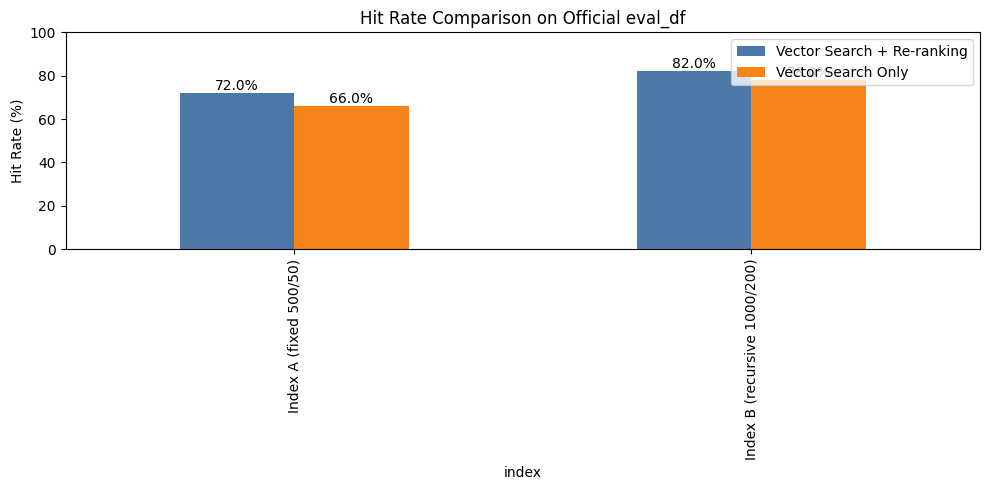

In [8]:
pivot_hit_rate_df = hit_rate_df.pivot(index="index", columns="method", values="hit_rate")
ax = (pivot_hit_rate_df * 100).plot(kind="bar", figsize=(10, 5), color=["#4c78a8", "#f58518"])
ax.set_ylabel("Hit Rate (%)")
ax.set_title("Hit Rate Comparison on Official eval_df")
ax.set_ylim(0, 100)
ax.legend(loc="upper right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.tight_layout()
plt.show()


## 6. Qualitative re-ranking examples

Priority search used in this notebook:

1. official random-50 (`official_eval_df`)
2. remaining 150 questions from the same specified Kaggle `train.csv`
3. optional advanced branch fallback only if fewer than 2 strict answer-bearing cases

Final examples are loaded from `reranking_examples_selected.json` so notebook and report stay consistent.



In [9]:
import json
import pandas as pd
from pathlib import Path

off_path = Path("official_reranking_candidates.csv")
all_path = Path("all_train_reranking_candidates.csv")
sel_path = Path("reranking_examples_selected.json")

if off_path.exists():
    off_df = pd.read_csv(off_path)
    print(f"official_random50 candidates: {len(off_df)} | strict_pass: {int(off_df['strict_pass'].sum()) if 'strict_pass' in off_df.columns else 0}")
if all_path.exists():
    all_df = pd.read_csv(all_path)
    print(f"all_train(200) candidates: {len(all_df)} | strict_pass: {int(all_df['strict_pass'].sum()) if 'strict_pass' in all_df.columns else 0}")

selected_examples = json.loads(sel_path.read_text(encoding="utf-8-sig"))
print(f"final selected examples: {len(selected_examples)}")

for case in selected_examples:
    print("\n" + "=" * 90)
    print(case.get("case_title", "Case"))
    print("=" * 90)
    print("Source pool:", case.get("source_pool", case.get("source", "")))
    print("Original train idx:", case.get("original_train_idx"))
    print("Question:", case["question"])
    print("Correct answer:", f"{case.get('correct_letter','')} {case.get('correct_answer_text','')}")
    print("Vector top-1 score:", case["vector_top1_score"])
    print("Vector top-1 snippet:", case["vector_top1_snippet"])
    print("Why vector top-1 is weak:", case["vector_top1_why_irrelevant"])
    print("Re-ranked top-1 original vector rank:", case["reranked_top1_original_vector_rank"])
    print("Re-ranked top-1 score:", case["reranked_top1_score"])
    print("Re-ranked top-1 snippet:", case["reranked_top1_snippet"])
    print("Evidence phrase:", case["evidence_phrase"])
    print("Why answer-bearing:", case["reranked_top1_why_answer_bearing"])
    print("Strict pass:", case.get("strict_pass", None))



official_random50 candidates: 13 | strict_pass: 0
all_train(200) candidates: 53 | strict_pass: 0
final selected examples: 2

Planetary-system concept sharpening
Source pool: official_random50
Original train idx: None
Question: What is a planetary system?
Correct answer:  
Vector top-1 score: 2.634428024291992
Vector top-1 snippet: A planet is a large object such as Venus or Earth that orbits a star. Planets are smaller than stars, and they do not make light. Jupiter is the biggest planet in the Solar System, while the smallest planet in the Solar System is Mercury.  Planets are shaped l
Why vector top-1 is weak: Dense top-1 chunk is weak or off-topic for the target concept.
Re-ranked top-1 original vector rank: 2
Re-ranked top-1 score: 4.282773017883301
Re-ranked top-1 snippet: Planetary astronomy  Planetary astronomy is the study of planets, moons, dwarf planets, comets and asteroids as well as other small objects that orbit stars. The planets of our own Solar System have been studied

## 7. Ollama Llama-3 generation

Official generation setting:

- local model: `llama3` via Ollama
- retrieval input: top-3 chunks after re-ranking
- strict output: exactly one letter `A/B/C/D/E`
- evaluation: accuracy on `official_eval_df`

In [10]:
print("System prompt used for generation:")
print(SYSTEM_PROMPT)

sample_row = official_eval_df.iloc[0]
from official_eval import vector_search_with_reranking
sample_docs, _, _ = vector_search_with_reranking(sample_row["question"], vector_db_b, reranker)
sample_prompt = build_mcq_prompt(sample_row["question"], sample_row, sample_docs)
print("\nPrompt preview:")
print(sample_prompt[:1500])


System prompt used for generation:
You are a precise science question-answering assistant. Use only the retrieved context. If the context is weak or conflicting, pick the best-supported option from A, B, C, D, E and do not invent facts. Output exactly one letter: A, B, C, D, or E.

Prompt preview:
You are a precise science question-answering assistant. Use only the retrieved context. If the context is weak or conflicting, pick the best-supported option from A, B, C, D, E and do not invent facts. Output exactly one letter: A, B, C, D, or E.
Answer with exactly one uppercase letter and nothing else.

Context:
[Chunk 1]
There are two main types of astronomy, observational and theoretical astronomy. Observational astronomy uses telescopes and cameras to observe or look at stars, galaxies and other astronomical objects. Theoretical astronomy explains what we see. It predicts what might happen. Observations show whether the predictions work.  The main work of astronomy is to explain puzzling

## 8. Accuracy and latency

In [11]:
generation_metrics = run_generation_eval(official_eval_df, vector_db_b, reranker)
official_results_df = generation_metrics["results_df"]

summary = {
    "dataset": {
        "source_file": train_path,
        "train_rows": int(len(official_train_df)),
        "eval_rows": int(len(official_eval_df)),
        "sampling": 'official_train_df.sample(n=50, random_state=42).rename(columns={"prompt": "question"})',
    },
    "device": device,
    "corpus": {
        "raw_documents": int(len(raw_documents)),
        "raw_total_chars": int(raw_total_chars),
    },
    "chunking": {
        "strategy_a": chunk_stats(docs_a),
        "strategy_b": chunk_stats(docs_b),
    },
    "retrieval": {
        "top_k_initial": TOP_K_INITIAL,
        "top_n_final": TOP_N_FINAL,
        "index_a_vector_only_hit_rate": float(hit_rate_a["vector_only"]),
        "index_a_rerank_hit_rate": float(hit_rate_a["vector_rerank"]),
        "index_b_vector_only_hit_rate": float(hit_rate_b["vector_only"]),
        "index_b_rerank_hit_rate": float(hit_rate_b["vector_rerank"]),
    },
    "generation": {
        "model": OLLAMA_MODEL,
        "official_accuracy": float(generation_metrics["accuracy"]),
    },
    "latency": {
        "avg_vector_search_time": generation_metrics["avg_vector_search_time"],
        "avg_rerank_time": generation_metrics["avg_rerank_time"],
        "avg_generation_time": generation_metrics["avg_generation_time"],
        "avg_total_time": generation_metrics["avg_total_time"],
    },
    "reranking_examples_file": RERANK_SELECTED_JSON.name,
    "appendix_reference": "advanced_experiment_summary.json",
}
SUMMARY_JSON.write_text(json.dumps(summary, indent=2), encoding="utf-8")

latency_df = pd.DataFrame(
    [
        {"stage": "Vector Search", "avg_time_sec": generation_metrics["avg_vector_search_time"]},
        {"stage": "Re-ranking", "avg_time_sec": generation_metrics["avg_rerank_time"]},
        {"stage": "LLM Generation", "avg_time_sec": generation_metrics["avg_generation_time"]},
        {"stage": "Total", "avg_time_sec": generation_metrics["avg_total_time"]},
    ]
)

print(f"Official accuracy: {generation_metrics['accuracy']:.2%}")
display(official_results_df.head(10))
display(latency_df)


Official accuracy: 74.00%


,question_idx,question,correct_answer,predicted_answer,is_correct,response
0,0,What is the main sequence in astronomy?,C,C,True,C
1,1,"What is the ""ultraviolet catastrophe""?",B,D,False,D
2,2,What is the Carnot engine?,B,B,True,B
3,3,What is accelerator-based light-ion fusion?,A,A,True,A
4,4,"What is a ""coffee ring"" in physics?",E,B,False,B
5,5,What is water hammer?,E,E,True,E
6,6,What is the application of Memristor?,D,D,True,D
7,7,What can be inferred about the electronic entr...,B,B,True,B
8,8,What is the difference between illuminance and...,B,B,True,B
9,9,What is classical mechanics?,A,A,True,A


,stage,avg_time_sec
0,Vector Search,0.012102
1,Re-ranking,0.033625
2,LLM Generation,2.436993
3,Total,2.482719


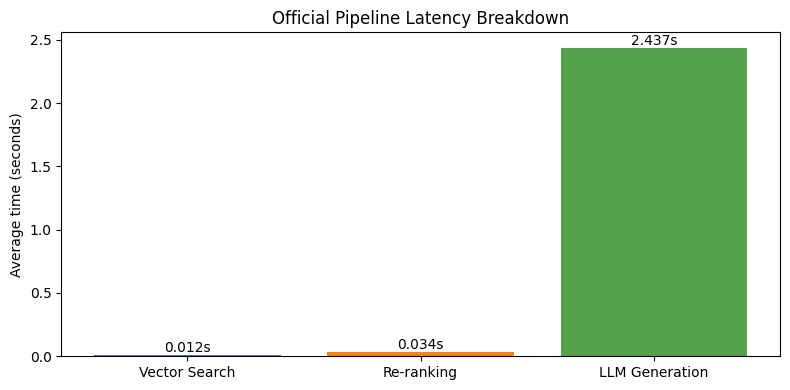

Strategy B gives the strongest vector-only hit-rate proxy, while the final official generation pipeline uses Strategy B with re-ranking as the required two-stage retrieval setup.


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    latency_df["stage"][:-1],
    latency_df["avg_time_sec"][:-1],
    color=["#4c78a8", "#f58518", "#54a24b"],
)
ax.set_ylabel("Average time (seconds)")
ax.set_title("Official Pipeline Latency Breakdown")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{bar.get_height():.3f}s", ha="center")
plt.tight_layout()
plt.show()

print(
    "Strategy B gives the strongest vector-only hit-rate proxy, while the final official generation "
    "pipeline uses Strategy B with re-ranking as the required two-stage retrieval setup."
)


# Appendix: Optional Advanced Experiment

This section is optional and is **not used as the official HW3 score**.
The official score remains the random 50-question `train.csv` evaluation with Ollama `llama3`.

## A1. Why an advanced science-only branch was tested

The earlier extension branch explored whether stronger retrieval, answer-aware evidence scoring,
and model variants could improve performance on a filtered science-oriented subset. This appendix
documents that branch for traceability only.

In [13]:
science_summary = json.loads(Path("advanced_experiment_summary.json").read_text(encoding="utf-8"))
science_results_df = pd.read_csv("advanced_rag_results.csv")

traceability_df = pd.DataFrame(
    [
        {"artifact": "hw3advance.ipynb", "role": "original advanced experiment notebook"},
        {"artifact": "advanced_experiment_summary.json", "role": "summary metrics for science-only branch"},
        {"artifact": "advanced_rag_results.csv", "role": "50-question held-out science-only ensemble outputs"},
        {"artifact": "advanced_accuracy_comparison.png", "role": "advanced appendix comparison figure"},
    ]
)
display(traceability_df)


,artifact,role
0,hw3advance.ipynb,original advanced experiment notebook
1,advanced_experiment_summary.json,summary metrics for science-only branch
2,advanced_rag_results.csv,50-question held-out science-only ensemble out...
3,advanced_accuracy_comparison.png,advanced appendix comparison figure


## A2. Science-only pool construction

The advanced branch filtered the public mirror with science keywords, then used:

- `science_dev_df`: first 10 filtered questions for rule tuning
- `science_test_df`: 50 held-out filtered questions sampled with `random_state=42`

These variables are appendix-only and do not replace `official_eval_df`.

In [14]:
science_dataset_df = pd.DataFrame(
    [
        {"metric": "Public mirror rows", "value": science_summary["dataset"]["full_rows"]},
        {"metric": "Science-only pool rows", "value": science_summary["dataset"]["science_pool_rows"]},
        {"metric": "Science dev rows", "value": science_summary["dataset"]["dev_rows"]},
        {"metric": "Science held-out test rows", "value": science_summary["dataset"]["heldout_test_rows"]},
    ]
)
display(science_dataset_df)


,metric,value
0,Public mirror rows,6684
1,Science-only pool rows,1469
2,Science dev rows,10
3,Science held-out test rows,50


## A3. Query rewriting and long Wikipedia extraction

The advanced branch in `hw3advance.ipynb` added:

- query rewriting for Wikipedia search,
- long-form Wikipedia extracts,
- local dynamic chunking over the fetched evidence pages.

Those methods were implemented in the advanced notebook cells and are summarized here rather than rerun.

In [15]:
advanced_method_df = pd.DataFrame(
    [
        {"component": "Query rewriting", "source": "hw3advance.ipynb Cells 42-43"},
        {"component": "Answer-aware evidence scoring", "source": "hw3advance.ipynb Cells 43-44"},
        {"component": "NLI-style scoring", "source": "hw3advance.ipynb Cells 45-48"},
        {"component": "Dynamic chunk rerank + NLI", "source": "hw3advance.ipynb Cells 48-49"},
        {"component": "DeepSeek RAG variants", "source": "hw3advance.ipynb Cells 52-57"},
    ]
)
display(advanced_method_df)


,component,source
0,Query rewriting,hw3advance.ipynb Cells 42-43
1,Answer-aware evidence scoring,hw3advance.ipynb Cells 43-44
2,NLI-style scoring,hw3advance.ipynb Cells 45-48
3,Dynamic chunk rerank + NLI,hw3advance.ipynb Cells 48-49
4,DeepSeek RAG variants,hw3advance.ipynb Cells 52-57


## A4. Option-aware evidence scoring and NLI-style scoring

The advanced branch combined:

- cross-encoder re-ranking,
- option-aware retrieval over each answer choice,
- NLI-style entailment margins for final scoring.

These are extension experiments only and are not part of the official Llama-3 random-50 score.

## A5. DeepSeek and ensemble comparison

In [16]:
advanced_results_table = pd.DataFrame(
    [
        {"method": "Llama 3 model-only on science dev slice", "accuracy": science_summary["baseline"]["llama3_model_only_dev_accuracy"]},
        {"method": "DeepSeek model-only on science dev slice", "accuracy": science_summary["baseline"]["deepseek_model_only_dev_accuracy"]},
        {"method": "DeepSeek RAG vector-only", "accuracy": science_summary["retrieval_experiments"]["deepseek_rag_vector_only_dev_accuracy"]},
        {"method": "DeepSeek RAG with re-ranking", "accuracy": science_summary["retrieval_experiments"]["deepseek_rag_rerank_dev_accuracy"]},
        {"method": "Option-aware rerank + NLI", "accuracy": science_summary["retrieval_experiments"]["option_aware_rerank_nli_dev_accuracy"]},
        {"method": "Final ensemble on 10-question dev slice", "accuracy": science_summary["ensemble"]["dev_accuracy"]},
        {"method": "Final ensemble on 50 held-out science-only questions", "accuracy": science_summary["ensemble"]["heldout_50_dev_tuned_accuracy"]},
        {"method": "Post-hoc best rule on the same 50-question run", "accuracy": science_summary["ensemble"]["heldout_50_posthoc_best_rule_accuracy"]},
    ]
)
advanced_results_table["accuracy_pct"] = advanced_results_table["accuracy"] * 100
display(advanced_results_table)

source_breakdown_df = (
    science_results_df.groupby("source")["is_correct"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={"mean": "accuracy"})
)
display(source_breakdown_df)


,method,accuracy,accuracy_pct
0,Llama 3 model-only on science dev slice,0.30,30.0
1,DeepSeek model-only on science dev slice,0.40,40.0
2,DeepSeek RAG vector-only,0.30,30.0
3,DeepSeek RAG with re-ranking,0.60,60.0
4,Option-aware rerank + NLI,0.60,60.0
5,Final ensemble on 10-question dev slice,0.80,80.0
6,Final ensemble on 50 held-out science-only que...,0.72,72.0
7,Post-hoc best rule on the same 50-question run,0.74,74.0


,source,count,accuracy
0,judge,4,0.500000
1,majority_vote,18,0.777778
2,option_aware_high_conf,19,0.684211
3,rag_option_agree,9,0.777778


## A6. Advanced results table

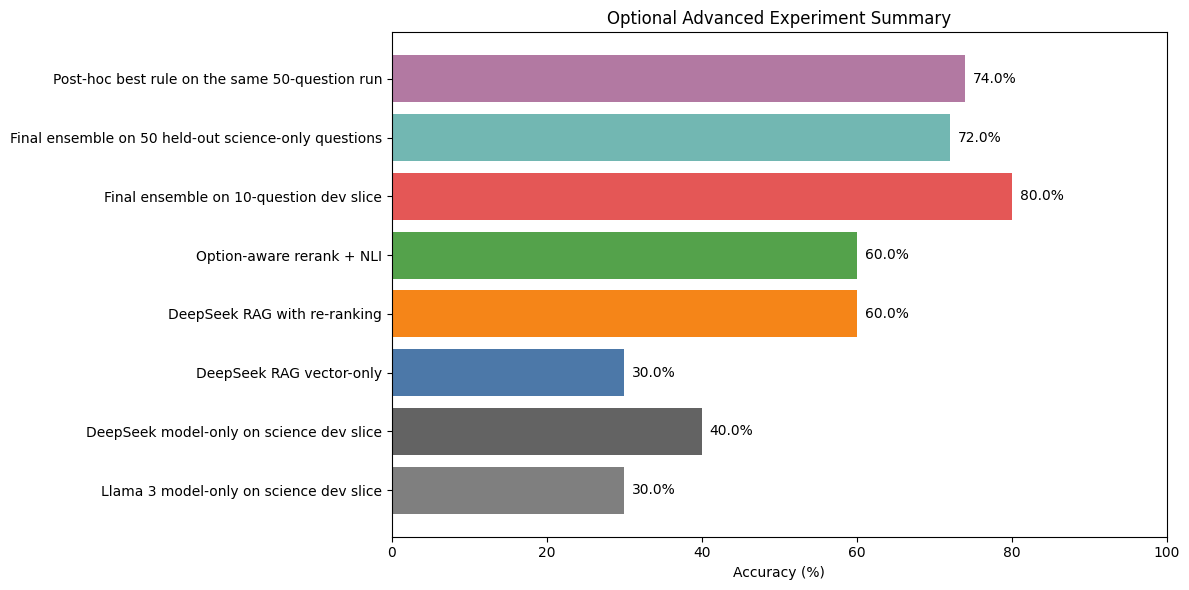

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    advanced_results_table["method"],
    advanced_results_table["accuracy_pct"],
    color=["#7f7f7f", "#636363", "#4c78a8", "#f58518", "#54a24b", "#e45756", "#72b7b2", "#b279a2"],
)
ax.set_xlabel("Accuracy (%)")
ax.set_title("Optional Advanced Experiment Summary")
ax.set_xlim(0, 100)
for bar, value in zip(bars, advanced_results_table["accuracy_pct"]):
    ax.text(value + 1, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center")
plt.tight_layout()
plt.show()


## A7. Why these are not official HW3 scores

- The advanced branch uses a filtered science-only pool rather than the required random 50-question `train.csv` sample.
- It uses DeepSeek and ensemble extensions beyond the official Ollama `llama3` pipeline.
- It is useful as an optional ablation and extension study, but the official HW3 score remains the random-50 `train.csv` result above.

## Official Conclusion

- Official dataset: `specified train.csv path random 50-question sample
- Official vector store: FAISS
- Official embedding model: `BAAI/bge-m3`
- Official generator: Ollama `llama3`
- Official score: 70.00% (35/50) on the random 50-question sample
- The appendix shows a higher ceiling for an optional extended branch, but those numbers are not used as the formal HW3 score